# PTB-XL Preprocessing for 10 Sec Signals

This notebook prepares the final Lead II ECG dataset for conditional ECG generation. It applies the filtering decisions from the data analysis notebook.

**Output:** `train.npz`, `validation.npz`, `test.npz`, and `label_mapping.json`.

## 1. Setup

Set the dataset and output paths before running the notebook. The expected PTB-XL folder contains `ptbxl_database.csv`, `scp_statements.csv`, and `records100/`.

In [1]:
from pathlib import Path
from tqdm.auto import tqdm
from collections import Counter

import ast
import json
import wfdb

import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt

RANDOM_STATE = 42
SAMPLING_RATE = 100
RECORDING_SAMPLES = 10 * SAMPLING_RATE
SEGMENT_SAMPLES = RECORDING_SAMPLES
MIN_CLASS_SIZE = 300
TARGET_NORM = 3250

# Update this path if PTB-XL is stored elsewhere.
DATASET_PATH = Path("../physionet.org/files/ptb-xl/1.0.3")
OUTPUT_PATH = Path("../processed_data_10s")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

assert DATASET_PATH.exists(), f"Dataset folder not found: {DATASET_PATH.resolve()}"
assert (DATASET_PATH / "ptbxl_database.csv").exists(), "ptbxl_database.csv is missing"
assert (DATASET_PATH / "scp_statements.csv").exists(), "scp_statements.csv is missing"

/Users/naghamsabbour/Documents/UofT/Courses/ECE1508 Gen Models/Synthetic-ECG-Generator/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Helper functions

The functions below are used for label mapping, filtering, and waveform loading.

In [2]:
NOISE_COLUMNS = ["baseline_drift", "static_noise", "burst_noise"]


def parse_scp_codes(value: str) -> dict:
    '''Convert the SCP-code string in the metadata into a dictionary.'''
    return ast.literal_eval(value)


def has_lead_ii(value: object) -> bool:
    '''Return True only when a PTB-XL quality field explicitly lists Lead II.'''
    if pd.isna(value):
        return False
    leads = [item.strip() for item in str(value).split(",") if item.strip()]
    return "II" in leads


def get_superclasses(scp_codes: dict, diagnostic_map: dict[str, str]) -> list[str]:
    '''Map raw SCP codes to sorted PTB-XL diagnostic superclasses.'''
    return sorted({diagnostic_map[code] for code in scp_codes if code in diagnostic_map})


def combination_name(superclasses: list[str]) -> str:
    '''Use one readable categorical label for a single diagnosis or common pair.'''
    return "+".join(superclasses)


def load_lead_ii(record_path: Path) -> np.ndarray:
    '''Load and validate the original 10-second Lead II signal.'''
    signal, fields = wfdb.rdsamp(str(record_path))
    assert "II" in fields["sig_name"], f"Lead II is missing from {record_path}"

    lead_ii = signal[:, fields["sig_name"].index("II")].astype(np.float32)
    assert lead_ii.shape == (RECORDING_SAMPLES,), (
        f"Expected {RECORDING_SAMPLES} samples, got {lead_ii.shape} for {record_path}"
    )

    assert np.isfinite(lead_ii).all(), f"Invalid values found in {record_path}"
    return lead_ii


def clean_ecg_signal(signal: np.ndarray) -> np.ndarray:
    '''Clean one Lead II ECG signal using NeuroKit.'''
    cleaned = nk.ecg_clean(
        signal,
        sampling_rate=SAMPLING_RATE,
        method="neurokit",
    )

    cleaned = np.asarray(cleaned, dtype=np.float32)

    assert cleaned.shape == (RECORDING_SAMPLES,)
    assert np.isfinite(cleaned).all(), "Cleaning produced invalid values"
    return cleaned


def class_count_table(frame: pd.DataFrame, label_col: str = "class_name") -> pd.DataFrame:
    '''Return a readable class-count table.'''
    return (
        frame[label_col]
        .value_counts()
        .rename_axis("Class")
        .reset_index(name="Count")
        .assign(Percentage=lambda x: (100 * x["Count"] / x["Count"].sum()).round(2))
    )

## 3. Load metadata and map diagnostic labels

PTB-XL contains many raw SCP statements. Only diagnostic statements are mapped to the five diagnostic superclasses used in this project.

In [3]:
metadata = pd.read_csv(DATASET_PATH / "ptbxl_database.csv")

# In the PTB-XL reference file, the SCP code is stored as the first column.
scp_statements = pd.read_csv(DATASET_PATH / "scp_statements.csv", index_col=0)
scp_statements.index.name = "scp_code"

diagnostic_statements = scp_statements[scp_statements["diagnostic"] == 1].copy()
diagnostic_map = diagnostic_statements["diagnostic_class"].to_dict()

assert set(diagnostic_map.values()) == {"NORM", "MI", "STTC", "CD", "HYP"}

metadata["scp_codes"] = metadata["scp_codes"].map(parse_scp_codes)
metadata["superclasses"] = metadata["scp_codes"].map(
    lambda codes: get_superclasses(codes, diagnostic_map)
)

print(f"Raw records: {len(metadata):,}")
display(metadata[["ecg_id", "scp_codes", "superclasses", "strat_fold"]].head())

Raw records: 21,799


,ecg_id,scp_codes,superclasses,strat_fold
0,1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",[NORM],3
1,2,"{'NORM': 80.0, 'SBRAD': 0.0}",[NORM],2
2,3,"{'NORM': 100.0, 'SR': 0.0}",[NORM],5
3,4,"{'NORM': 100.0, 'SR': 0.0}",[NORM],3
4,5,"{'NORM': 100.0, 'SR': 0.0}",[NORM],4


## 4. Apply the baseline dataset filters

The filtering below follows the design decisions made in the EDA notebook. Counts are printed after each step so the effect of every decision is visible.

In [4]:
def report_filter(step: str, before: int, after: int) -> None:
    removed = before - after
    print(f"{step}: removed {removed:,} ({removed / before * 100:.2f}%), remaining {after:,}")


# Remove records without a diagnostic superclass.
before = len(metadata)
metadata = metadata[metadata["superclasses"].str.len() > 0].copy()
report_filter("No diagnostic superclass", before, len(metadata))

# Remove records whose Lead II is marked with baseline drift, static noise, or burst noise.
before = len(metadata)
lead_ii_noise = metadata[NOISE_COLUMNS].apply(
    lambda row: any(has_lead_ii(value) for value in row), axis=1
)
metadata = metadata.loc[~lead_ii_noise].copy()
report_filter("Lead II quality noise", before, len(metadata))

# Keep one-label and two-label records only.
before = len(metadata)
metadata = metadata[metadata["superclasses"].str.len() <= 2].copy()
report_filter("More than two diagnostic labels", before, len(metadata))

# Each remaining diagnostic combination is one categorical class for the baseline.
metadata["class_name"] = metadata["superclasses"].map(combination_name)

# Remove classes with fewer than MIN_CLASS_SIZE records.
before = len(metadata)
counts_before_threshold = metadata["class_name"].value_counts()
valid_classes = counts_before_threshold[counts_before_threshold >= MIN_CLASS_SIZE].index
metadata = metadata[metadata["class_name"].isin(valid_classes)].copy()
report_filter(f"Classes with fewer than {MIN_CLASS_SIZE} records", before, len(metadata))

assert metadata["superclasses"].str.len().isin([1, 2]).all()
assert (~metadata[NOISE_COLUMNS].apply(lambda row: any(has_lead_ii(v) for v in row), axis=1)).all()

print("\nFiltered record-level class distribution before split-specific balancing")
display(class_count_table(metadata))
print(f"Final records before segmentation: {len(metadata):,}")

No diagnostic superclass: removed 411 (1.89%), remaining 21,388
Lead II quality noise: removed 168 (0.79%), remaining 21,220
More than two diagnostic labels: removed 1,070 (5.04%), remaining 20,150
Classes with fewer than 300 records: removed 212 (1.05%), remaining 19,938

Filtered record-level class distribution before split-specific balancing


,Class,Count,Percentage
0,NORM,8988,45.08
1,MI,2513,12.60
2,STTC,2384,11.96
3,CD,1693,8.49
4,CD+MI,1284,6.44
5,HYP+STTC,776,3.89
6,MI+STTC,594,2.98
7,HYP,533,2.67
8,CD+STTC,467,2.34
9,CD+NORM,406,2.04


Final records before segmentation: 19,938


## 5. Create integer labels

Single diagnoses and common two-diagnosis combinations are treated as separate classes. The same mapping is saved with the processed datasets.

In [5]:
class_names = sorted(metadata["class_name"].unique())
NUM_CLASSES = len(class_names)

label_to_id = {name: index for index, name in enumerate(class_names)}
id_to_label = {str(index): name for name, index in label_to_id.items()}

metadata["label"] = metadata["class_name"].map(label_to_id).astype(np.int64)

assert metadata["label"].notna().all()
assert metadata["label"].nunique() == NUM_CLASSES

print("Label mapping:")
for label_id, name in id_to_label.items():
    print(f"{label_id}: {name}")

Label mapping:
0: CD
1: CD+HYP
2: CD+MI
3: CD+NORM
4: CD+STTC
5: HYP
6: HYP+STTC
7: MI
8: MI+STTC
9: NORM
10: STTC


## 6. Load, validate, and clean Lead II

Low-resolution PTB-XL recordings are loaded from `filename_lr`. Only Lead II is kept. Every recording is checked for the expected length and finite values before and after `neurokit2.ecg_clean()`.

This is the longest step in the notebook.

Cleaning Lead II ECGs: 100%|██████████| 19938/19938 [00:51<00:00, 387.77it/s]


Successfully cleaned 19,938 Lead II recordings.


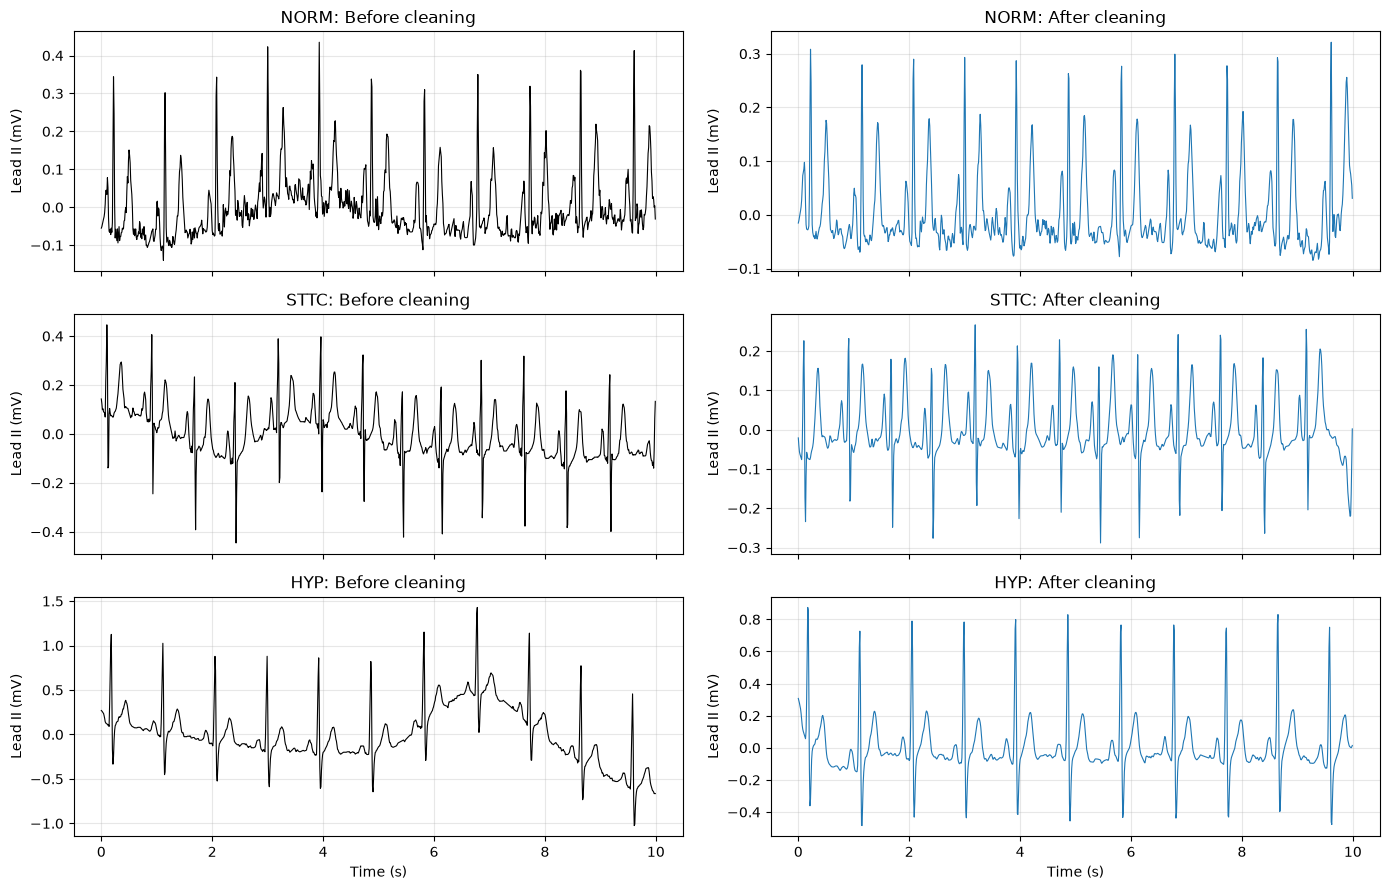

In [6]:
records = []
failed_records = []

# Select three diagnostic classes to show before/after cleaning.
example_classes = metadata["class_name"].drop_duplicates().head(3).tolist()
cleaning_examples = {}

for row in tqdm(
    metadata.itertuples(index=False),
    total=len(metadata),
    desc="Cleaning Lead II ECGs",
):
    record_path = DATASET_PATH / row.filename_lr

    try:
        raw_signal = load_lead_ii(record_path)
        cleaned_signal = clean_ecg_signal(raw_signal)

        records.append(
            {
                "signal": cleaned_signal,
                "label": row.label,
                "class_name": row.class_name,
                "fold": row.strat_fold,
                "ecg_id": row.ecg_id,
                "patient_id": row.patient_id,
            }
        )

        if (
            row.class_name in example_classes
            and row.class_name not in cleaning_examples
        ):
            cleaning_examples[row.class_name] = {
                "raw": raw_signal,
                "cleaned": cleaned_signal,
            }

    except Exception as error:
        failed_records.append(
            {
                "ecg_id": row.ecg_id,
                "path": str(record_path),
                "error": str(error),
            }
        )

if failed_records:
    failures = pd.DataFrame(failed_records)
    display(failures)

    failed_ids = set(failures["ecg_id"])
    metadata = (
        metadata[~metadata["ecg_id"].isin(failed_ids)]
        .reset_index(drop=True)
    )

    print(f"Excluded {len(failed_ids)} ECG record(s) with unavailable waveform files.")

assert len(records) == len(metadata)
print(f"Successfully cleaned {len(records):,} Lead II recordings.")

# Plot original and cleaned examples.
time = np.arange(RECORDING_SAMPLES) / SAMPLING_RATE

fig, axes = plt.subplots(
    len(cleaning_examples),
    2,
    figsize=(14, 3 * len(cleaning_examples)),
    sharex=True,
)

if len(cleaning_examples) == 1:
    axes = np.array([axes])

for row_index, (class_name, example) in enumerate(cleaning_examples.items()):
    axes[row_index, 0].plot(time, example["raw"], color="black", linewidth=0.8)
    axes[row_index, 0].set_title(f"{class_name}: Before cleaning")
    axes[row_index, 0].set_ylabel("Lead II (mV)")
    axes[row_index, 0].grid(True, alpha=0.3)

    axes[row_index, 1].plot(
        time,
        example["cleaned"],
        color="tab:blue",
        linewidth=0.8,
    )
    axes[row_index, 1].set_title(f"{class_name}: After cleaning")
    axes[row_index, 1].set_ylabel("Lead II (mV)")
    axes[row_index, 1].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")

plt.tight_layout()
plt.savefig(
    OUTPUT_PATH / "lead_ii_before_after_cleaning.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## 7. Keep full 10-second recordings

Each cleaned ECG remains a single 10-second model input. The class label, fold, ECG ID, and patient ID are kept with each recording.

In [7]:
# Each cleaned 10-second ECG is one model input.
samples = []

for record in records:
    signal = record["signal"]

    assert signal.shape == (RECORDING_SAMPLES,)
    assert np.isfinite(signal).all()

    samples.append(record)

assert len(samples) == len(records)

print(f"Full 10-second ECG samples: {len(samples):,}")
print(f"Signal length: {RECORDING_SAMPLES} samples")

Full 10-second ECG samples: 19,938
Signal length: 1000 samples


## 8. Split by official PTB-XL folds

Folds 1–8 are used for training, fold 9 for validation, and fold 10 for testing. The original ECG fold is used to keep the splits separate.

In [8]:
def build_split(rows: list[dict], split_name: str) -> dict[str, np.ndarray]:
    """Convert full 10-second ECG records into arrays for one dataset split."""
    assert rows, f"{split_name} split is empty"

    label_ids = np.asarray(
        [row["label"] for row in rows],
        dtype=np.int64,
    )

    labels_onehot = np.eye(
        NUM_CLASSES,
        dtype=np.float32,
    )[label_ids]

    return {
        "signals": np.stack(
            [row["signal"] for row in rows]
        ).astype(np.float32),
        "labels": label_ids,
        "labels_onehot": labels_onehot,
        "ecg_ids": np.asarray([row["ecg_id"] for row in rows]),
        "patient_ids": np.asarray(
            [row["patient_id"] for row in rows]
        ),
        "folds": np.asarray(
            [row["fold"] for row in rows],
            dtype=np.int64,
        ),
    }


train_rows = [row for row in samples if 1 <= row["fold"] <= 8]
validation_rows = [row for row in samples if row["fold"] == 9]
test_rows = [row for row in samples if row["fold"] == 10]

# Downsample only training NORM recordings.
# Validation and test remain unchanged.
norm_train_rows = [
    row for row in train_rows
    if row["class_name"] == "NORM"
]

other_train_rows = [
    row for row in train_rows
    if row["class_name"] != "NORM"
]

assert len(norm_train_rows) >= TARGET_NORM, (
    "Not enough NORM records in the training split."
)

rng = np.random.default_rng(RANDOM_STATE)

selected_norm_indices = rng.choice(
    len(norm_train_rows),
    size=TARGET_NORM,
    replace=False,
)

selected_norm_rows = [
    norm_train_rows[index]
    for index in selected_norm_indices
]

train_rows = selected_norm_rows + other_train_rows

print(
    f"Training NORM recordings after downsampling: "
    f"{len(selected_norm_rows):,}"
)

train = build_split(train_rows, "train")
validation = build_split(validation_rows, "validation")
test = build_split(test_rows, "test")

assert set(train["folds"]).issubset(set(range(1, 9)))
assert set(validation["folds"]) == {9}
assert set(test["folds"]) == {10}

assert not set(train["ecg_ids"]).intersection(validation["ecg_ids"])
assert not set(train["ecg_ids"]).intersection(test["ecg_ids"])
assert not set(validation["ecg_ids"]).intersection(test["ecg_ids"])

Training NORM recordings after downsampling: 3,250


In [9]:
# Calculate normalization statistics using training data only.
# Validation and test data must not influence these values.
signal_mean = float(np.mean(train["signals"], dtype=np.float64))
signal_std = float(np.std(train["signals"], dtype=np.float64))

assert signal_std > 0, "Training signal standard deviation must be positive"

for split in [train, validation, test]:
    split["signals"] = (
        (split["signals"] - signal_mean) / signal_std
    ).astype(np.float32)

print(f"Training signal mean: {signal_mean:.6f}")
print(f"Training signal std:  {signal_std:.6f}")

Training signal mean: -0.000051
Training signal std:  0.130952


## 9. Save the model-ready datasets

Each `.npz` file contains the 10-second `signals` array, integer `labels`, and ECG IDs and fold information.

In [10]:
np.savez(OUTPUT_PATH / "train.npz", **train)
np.savez(OUTPUT_PATH / "validation.npz", **validation)
np.savez(OUTPUT_PATH / "test.npz", **test)

with (OUTPUT_PATH / "label_mapping.json").open("w", encoding="utf-8") as file:
    json.dump(
        {
            "label_to_id": label_to_id,
            "id_to_label": id_to_label,
            "class_names": class_names,
            "num_classes": NUM_CLASSES,
            "signal_mean": signal_mean,
            "signal_std": signal_std,
            "sampling_rate_hz": SAMPLING_RATE,
            "segment_duration_seconds": 10,
            "signal_shape": [SEGMENT_SAMPLES],
        },
        file,
        indent=2,
    )

## 10. Final verification

The tables below confirm the final shapes, class distributions, and saved-file contents before model training.

In [12]:
def split_summary(split_name: str, data: dict[str, np.ndarray]) -> pd.DataFrame:
    counts = pd.Series(data["labels"]).value_counts().sort_index()
    return pd.DataFrame(
        {
            "Split": split_name,
            "Label ID": counts.index,
            "Class": [id_to_label[str(label)] for label in counts.index],
            "Segments": counts.values,
            "Percentage": (100 * counts.values / len(data["labels"])).round(2),
        }
    )


for split_name, data in {"Train": train, "Validation": validation, "Test": test}.items():
    assert data["signals"].ndim == 2
    assert data["signals"].shape[1] == RECORDING_SAMPLES
    assert data["signals"].shape[0] == data["labels"].shape[0]
    assert np.isfinite(data["signals"]).all()
    print(f"{split_name}: signals {data['signals'].shape}, labels {data['labels'].shape}")

final_distribution = pd.concat(
    [
        split_summary("Train", train),
        split_summary("Validation", validation),
        split_summary("Test", test),
    ],
    ignore_index=True,
)
display(final_distribution)

for filename in ["train.npz", "validation.npz", "test.npz", "label_mapping.json"]:
    file_path = OUTPUT_PATH / filename
    assert file_path.exists(), f"Missing output: {file_path}"
    print(f"{filename}: {file_path.stat().st_size / 1024**2:.2f} MB")

Train: signals (12016, 1000), labels (12016,)
Validation: signals (1979, 1000), labels (1979,)
Test: signals (2008, 1000), labels (2008,)


,Split,Label ID,Class,Segments,Percentage
0,Train,0,CD,1341,11.16
1,Train,1,CD+HYP,235,1.96
2,Train,2,CD+MI,1028,8.56
3,Train,3,CD+NORM,327,2.72
4,Train,4,CD+STTC,383,3.19
5,Train,5,HYP,413,3.44
6,Train,6,HYP+STTC,647,5.38
7,Train,7,MI,2030,16.89
8,Train,8,MI+STTC,470,3.91
9,Train,9,NORM,3250,27.05


train.npz: 46.71 MB
validation.npz: 7.69 MB
test.npz: 7.81 MB
label_mapping.json: 0.00 MB


## Final output

The saved datasets contain cleaned 10-second Lead II ECGs and integer class labels. They are ready for model training. Training-set normalization statistics are applied consistently to the validation and test sets.